# Proyecto 1: Búsqueda en Espacios de Estados
* **Problema:** Taxi en la Ciudad
* **Materia:** Inteligencia Artificial — Facultad de Ingeniería Eléctrica, UMSNH
* **Profesor:** Dr. José Ortiz Béjar
* **Equipo:**
    * Moisés Moreno Cortez
    * César Ambris Salguero
* **Repositorio en GitHub:** [https://github.com/MoisesMorenoUMSNH/baile](https://github.com/MoisesMorenoUMSNH/baile)


## 2. Descripción del problema
Controlamos un taxi dentro de una ciudad representada como una cuadrícula. En la ciudad hay calles libres y obstáculos (calles cerradas o edificios).

La misión consta de dos etapas:
1. Conducir hasta la posición del **pasajero** y recogerlo.
2. Transportar al pasajero hasta el **destino final**.

El taxi solo puede moverse en 4 direcciones (Arriba, Abajo, Izquierda y Derecha), cada movimiento cuesta 1 paso, y el objetivo es encontrar la ruta más corta posible esquivando los obstáculos.


In [92]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import src.SimpleSearch as sp
from src.taxi import CiudadTaxi

def generar_obstaculos(ancho, alto, porcentaje, reservas, semilla):
    # Calles cerradas al azar (semilla fija para reproducibilidad)
    random.seed(semilla)
    total_obstaculos = int(ancho * alto * porcentaje)
    obstaculos = set()
    while len(obstaculos) < total_obstaculos:
        posicion = (random.randint(0, ancho - 1), random.randint(0, alto - 1))
        if posicion not in reservas:
            obstaculos.add(posicion)
    return obstaculos

def dibujar_ciudad(ciudad, posicion_taxi, ruta=None, titulo="Taxi en la Ciudad"):
    # Cuadrícula de la ciudad, obstáculos y trayectoria
    fig, ax = plt.subplots(figsize=(9, 8), dpi=100)
    ax.set_aspect("equal")
    ax.set_facecolor("whitesmoke")

    # Obstáculos (calles bloqueadas)
    for obstaculo_x, obstaculo_y in ciudad.obstaculos:
        ax.add_patch(patches.Rectangle((obstaculo_x - 0.5, obstaculo_y - 0.5), 1, 1, facecolor="dimgray", edgecolor="black"))

    # Condiciones de recogida del pasajero y viaje a la meta
    if ruta:
        ruta_recogida = [paso[0][0] for paso in ruta if not paso[0][1]]
        ruta_destino = [paso[0][0] for paso in ruta if paso[0][1]]
        if ruta_recogida and ruta_destino:
            ruta_destino = [ruta_recogida[-1]] + ruta_destino
        if ruta_recogida:
            ax.plot(*zip(*ruta_recogida), color="darkorange", lw=3, ls="--", label="Fase 1: Recogida", zorder=4)
        if ruta_destino:
            ax.plot(*zip(*ruta_destino), color="mediumseagreen", lw=3, ls="-", label="Fase 2: Destino", zorder=4)

    # Marcadores del Taxi, Pasajero y Destino
    taxi_x, taxi_y = posicion_taxi
    ax.scatter(taxi_x, taxi_y, marker="s", s=320, facecolor="gold", edgecolor="black", lw=1.8, zorder=6)
    ax.text(taxi_x, taxi_y, "TAXI", fontsize=6.5, fontweight="bold", ha="center", va="center", color="black", zorder=7)

    pasajero_x, pasajero_y = ciudad.pos_pasajero
    ax.scatter(pasajero_x, pasajero_y, marker="o", s=280, facecolor="deepskyblue", edgecolor="black", lw=1.8, zorder=6)
    ax.text(pasajero_x, pasajero_y, "P", fontsize=9, fontweight="bold", ha="center", va="center", color="black", zorder=7)

    destino_x, destino_y = ciudad.pos_destino
    ax.scatter(destino_x, destino_y, marker="D", s=280, facecolor="mediumseagreen", edgecolor="black", lw=1.8, zorder=6)
    ax.text(destino_x, destino_y, "D", fontsize=9, fontweight="bold", ha="center", va="center", color="black", zorder=7)

    ax.scatter([], [], marker="s", color="dimgray", label="Obstáculo")
    ax.scatter([], [], marker="s", facecolor="gold", edgecolor="black", lw=1.5, s=120, label=f"Taxi {posicion_taxi}")
    ax.scatter([], [], marker="o", facecolor="deepskyblue", edgecolor="black", lw=1.5, s=120, label=f"Pasajero {ciudad.pos_pasajero}")
    ax.scatter([], [], marker="D", facecolor="mediumseagreen", edgecolor="black", lw=1.5, s=120, label=f"Destino {ciudad.pos_destino}")

    # Ejes y cuadrícula
    ax.set_xlim(-0.5, ciudad.ancho - 0.5)
    ax.set_ylim(-0.5, ciudad.alto - 0.5)
    ax.set_xticks(range(ciudad.ancho))
    ax.set_yticks(range(ciudad.alto))
    ax.tick_params(axis="both", labelsize=8)

    ax.set_xticks([x - 0.5 for x in range(ciudad.ancho + 1)], minor=True)
    ax.set_yticks([y - 0.5 for y in range(ciudad.alto + 1)], minor=True)
    ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", size=0)

    ax.set_title(titulo, fontsize=13, fontweight="bold", pad=12)
    ax.legend(bbox_to_anchor=(1.03, 1), loc="upper left", frameon=True, facecolor="white")
    plt.tight_layout()
    plt.show()

dibujar_ciudad_pro = dibujar_ciudad


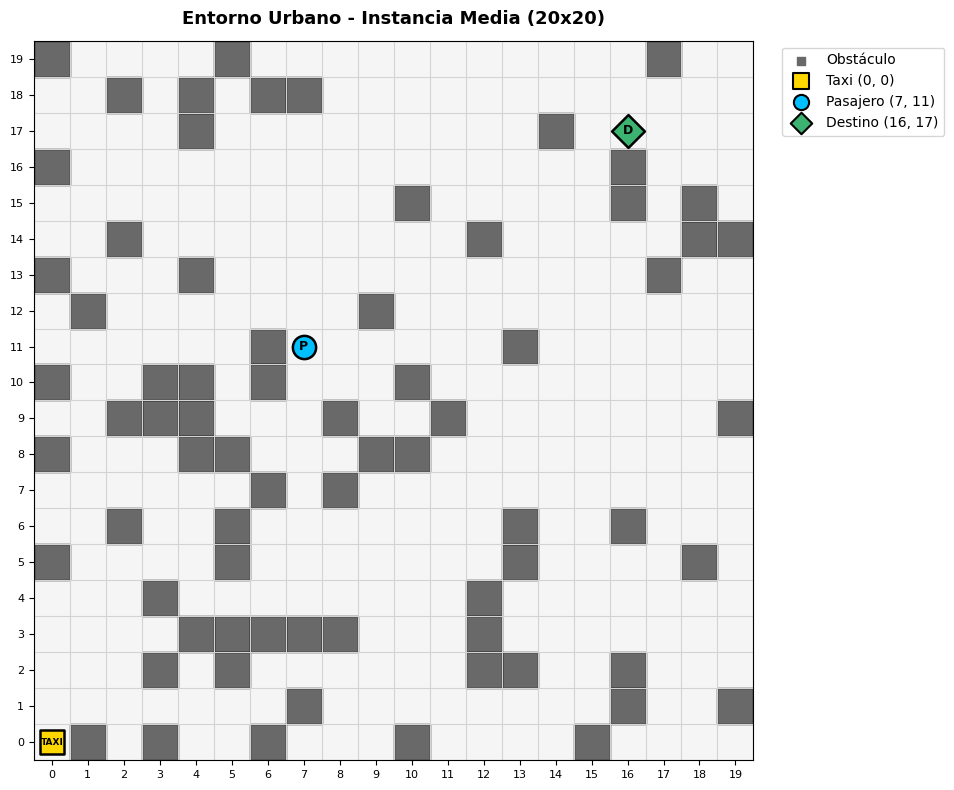

In [93]:
# Mostramos el mapa de la instancia Media (20x20) como ejemplo inicial
obstaculos_media = generar_obstaculos(20, 20, 0.18, {(0, 0), (7, 11), (16, 17)}, semilla=20)
ciudad_media = CiudadTaxi(20, 20, obstaculos_media, pos_pasajero=(7, 11), pos_destino=(16, 17))
dibujar_ciudad(ciudad_media, posicion_taxi=(0, 0), titulo="Entorno Urbano - Instancia Media (20x20)")


## 3. Modelado formal
* **Estado:** Lo representamos con una tupla: `((x, y), lleva_pasajero)`.
  * **¿Por qué solo estos datos?** Son los mínimos necesarios: `(x, y)` indica la coordenada del taxi y `lleva_pasajero` es un booleano (`True`/`False`) que indica si el cliente está a bordo. No guardamos el historial de pasos para no crear estados repetidos innecesarios.
  * **¿Por qué una tupla?** En Python las tuplas son *inmutables*. Esto permite que el algoritmo las guarde en una tabla hash (conjunto `set`) para recordar qué casillas ya visitó y evitar dar vueltas en círculos infinitos.
* **Operador Sucesor:** Evalúa los 4 movimientos posibles (Arriba, Abajo, Izquierda, Derecha). Si la casilla vecina está dentro del mapa y no es obstáculo, genera un nodo hijo con costo $+1$. Si el taxi pisa la casilla del pasajero, `lleva_pasajero` cambia a `True`.
* **Condición de Meta:** Se cumple cuando el taxi llega a las coordenadas del destino **y** el pasajero ya está a bordo (`lleva_pasajero == True`).
* **Función Heurística ($h_1$):** Distancia Manhattan calculada en dos etapas:
  $$h_1(n) = \begin{cases} d_M(\text{taxi}, \text{pasajero}) + d_M(\text{pasajero}, \text{destino}) & \text{si todavía no sube el pasajero} \\ d_M(\text{taxi}, \text{destino}) & \text{si el pasajero ya está a bordo} \end{cases}$$


## 4. Estimación del tamaño del espacio de búsqueda
* **Factor de ramificación ($b$):** En una casilla libre hay 4 movimientos posibles. Tomando en cuenta las esquinas, bordes y calles cerradas (~18%), el promedio real de caminos libres es de $b \approx 2.7$.
* **Profundidad de la solución ($d$):** En el mapa más grande ($30 \times 30$), la ruta óptima tiene una longitud de $d \approx 50$ pasos.
* **Búsqueda en árbol (sin recordar visitados):** $b^d \approx 2.7^{50} \approx 10^{21}$ nodos. Sería imposible de resolver en una computadora porque el taxi se quedaría atrapado repitiendo caminos.
* **Búsqueda en grafo (recordando casillas visitadas):** El número máximo de estados posibles es:
  $$|S| \le 30 \times 30 \times 2 = 1,800 \text{ estados}$$
  Como $1,800$ es un número pequeño (mucho menor al límite práctico de $10^6$), la búsqueda con detección de repetidos es **totalmente viable** y encuentra la solución en milisegundos.


## 5. Implementación del problema
La lógica del entorno está programada en el archivo [src/taxi.py](src/taxi.py) dentro de la clase `CiudadTaxi`.
Aquí realizamos una prueba rápida para comprobar que el estado inicial, los sucesores y las heurísticas funcionen correctamente:


In [94]:
# Verificamos los métodos de CiudadTaxi
ciudad_prueba = CiudadTaxi(10, 10, {(1, 1), (1, 2)}, pos_pasajero=(3, 3), pos_destino=(8, 8))
nodo_inicial = sp.node(((0, 0), False))

print("Estado inicial:", nodo_inicial.state)
print("Sucesores válidos:", len(ciudad_prueba.sucesor(nodo_inicial)))
print("Heurística Manhattan (h1):", ciudad_prueba.h_manhattan(nodo_inicial))
print("Heurística Euclidiana (h2):", round(ciudad_prueba.h_euclidiana(nodo_inicial), 2))


Estado inicial: ((0, 0), False)
Sucesores válidos: 2
Heurística Manhattan (h1): 16
Heurística Euclidiana (h2): 11.31


## 6. Protocolo experimental
Para evaluar los algoritmos de búsqueda seguimos los requerimientos de la rúbrica:
1. **Tres niveles de dificultad:** Instancias Fácil ($15 \times 15$), Media ($20 \times 20$) y Difícil ($30 \times 30$), con semillas fijas (`seed=10, 20, 30`) para que las pruebas sean reproducibles.
2. **Cuatro estrategias obligatorias:**
   * **BFS:** Búsqueda en anchura (ciega).
   * **DFS:** Búsqueda en profundidad (ciega).
   * **A\* con $h=0$:** Búsqueda de Costo Uniforme (Dijkstra).
   * **A\* con Manhattan:** Nuestra heurística informada ($h_1$).
3. **Mismo límite de iteraciones:** `MAX_ITERACIONES = 500000` para todos los algoritmos.
4. **Entorno de ejecución (Sección 6.4):** Fedora 44 Linux (arquitectura x86_64 de 64 bits), ejecutado en Python 3.14.
5. **¿Las soluciones difieren en longitud? (Sección 6.2):** **Sí.** BFS y A* garantizan encontrar la ruta óptima con la mínima cantidad de pasos. En cambio, DFS se pierde en ramas profundas y devuelve rutas muy largas con desvíos innecesarios (por ejemplo, 318 pasos en la difícil en lugar de los 52 pasos óptimos).


In [81]:
# Configuracion de las instancias de prueba (Fácil, Media y Difícil)
obstaculos_facil = generar_obstaculos(15, 15, 0.10, {(0, 0), (4, 4), (8, 8)}, semilla=10)
obstaculos_dificil = generar_obstaculos(30, 30, 0.22, {(1, 1), (14, 15), (27, 27)}, semilla=30)

instancias = [
    {
        "nombre": "Fácil (15x15)",
        "ciudad": CiudadTaxi(15, 15, obstaculos_facil, pos_pasajero=(4, 4), pos_destino=(8, 8)),
        "inicio": ((0, 0), False)
    },
    {
        "nombre": "Media (20x20)",
        "ciudad": ciudad_media,
        "inicio": ((0, 0), False)
    },
    {
        "nombre": "Difícil (30x30)",
        "ciudad": CiudadTaxi(30, 30, obstaculos_dificil, pos_pasajero=(14, 15), pos_destino=(27, 27)),
        "inicio": ((1, 1), False)
    }
]
print("Instancias configuradas con éxito.")


Instancias configuradas con éxito.


In [82]:
import time
import pandas as pd

MAX_ITERACIONES = 500000
filas_resultados = []

# Evaluamos las 4 estrategias en cada una de las tres ciudades
for instancia in instancias:
    ciudad = instancia["ciudad"]
    nodo_inicio = sp.node(instancia["inicio"])

    # 4 estrategias: Nombre en tabla, método SimpleSearch, heurística
    estrategias = [
        ("BFS", "bfs", None),                          # Anchura (ciega, sin heurística)
        ("DFS", "dfs", None),                          # Profundidad (ciega, sin heurística)
        ("A* (h=0)", "a*", lambda nodo, meta=None: 0), # Costo uniforme / Dijkstra
        ("A* (tu h)", "a*", ciudad.h_manhattan)         # A* con heurística Manhattan admisible
    ]

    for nombre_estrategia, metodo_busqueda, funcion_heuristica in estrategias:
        tiempo_inicio = time.time()
        busqueda = sp.TreeSearch(
            nodo_inicio,
            ciudad.sucesor,
            ciudad.meta,
            strategy=metodo_busqueda,
            heuristic=funcion_heuristica
        )
        solucion = busqueda.find(max_iter=MAX_ITERACIONES)
        tiempo_total = round(time.time() - tiempo_inicio, 4)

        longitud_ruta = len(solucion.getPath()) - 1 if solucion else "Sin solución"
        costo_ruta = solucion.cost if solucion else "N/A"

        filas_resultados.append([
            instancia["nombre"],
            nombre_estrategia,
            busqueda.iterations,
            tiempo_total,
            longitud_ruta,
            costo_ruta
        ])

columnas_resultados = ["Instancia", "Estrategia", "Nodos expandidos", "Tiempo (s)", "Longitud", "Costo g"]
df_resultados = pd.DataFrame(filas_resultados, columns=columnas_resultados)
df_resultados


,Instancia,Estrategia,Nodos expandidos,Tiempo (s),Longitud,Costo g
0,Fácil (15x15),BFS,192,0.0010,16,16
1,Fácil (15x15),DFS,240,0.0018,34,34
2,Fácil (15x15),A* (h=0),194,0.0012,16,16
3,Fácil (15x15),A* (tu h),34,0.0002,16,16
4,Media (20x20),BFS,570,0.0024,35,35
5,Media (20x20),DFS,312,0.0014,125,125
6,Media (20x20),A* (h=0),575,0.0031,35,35
7,Media (20x20),A* (tu h),120,0.0008,35,35
8,Difícil (30x30),BFS,1330,0.0153,52,52
9,Difícil (30x30),DFS,842,0.0042,318,318


In [83]:
# Verificación de correctitud
filas_verificacion = []

for instancia in instancias:
    nombre_instancia = instancia["nombre"]
    datos_instancia = df_resultados[df_resultados["Instancia"] == nombre_instancia]

    longitud_bfs = datos_instancia[datos_instancia["Estrategia"] == "BFS"]["Longitud"].values[0]
    longitud_astar = datos_instancia[datos_instancia["Estrategia"] == "A* (tu h)"]["Longitud"].values[0]

    assert longitud_bfs == longitud_astar, f"Error: A* no fue óptimo en {nombre_instancia}."
    filas_verificacion.append([nombre_instancia, longitud_bfs, longitud_astar, "Coinciden (Óptimo)"])

columnas_verificacion = ["Instancia", "Longitud BFS", "Longitud A*", "Resultado"]
df_verificacion = pd.DataFrame(filas_verificacion, columns=columnas_verificacion)

print("Correctitud comprobada: A* devuelve exactamente la misma longitud óptima que BFS.")
df_verificacion


Correctitud comprobada: A* devuelve exactamente la misma longitud óptima que BFS.


,Instancia,Longitud BFS,Longitud A*,Resultado
0,Fácil (15x15),16,16,Coinciden (Óptimo)
1,Media (20x20),35,35,Coinciden (Óptimo)
2,Difícil (30x30),52,52,Coinciden (Óptimo)


## 7. Análisis de la heurística
Respondemos puntualmente las cuatro preguntas de la rúbrica:

1. **¿Qué mide y por qué es una estimación razonable?**
   Mide la distancia Manhattan ideal en dos etapas: del taxi al pasajero, y del pasajero a la meta. Es una estimación realista porque en una ciudad en cuadrícula el taxi solo puede doblar esquinas en ángulos de 90 grados.
2. **¿Es admisible? (Justificación por relajación)**
   **Sí, es totalmente admisible.** Si aplicamos *relajación* (imaginamos que quitamos todos los edificios y obstáculos), el taxi tardaría exactamente los pasos que calcula Manhattan. Al volver a colocar los obstáculos, el camino real solo puede ser igual o más largo, jamás más corto. Por lo tanto, nunca sobreestima el costo real ($h(n) \le h^*(n)$).
3. **¿Cuánto ayuda frente a $h=0$?**
   Ayuda de forma drástica. En la instancia difícil, A* con $h=0$ tiene que explorar 1,340 nodos para encontrar la meta, mientras que con nuestra heurística Manhattan solo necesita explorar 199 nodos (un ahorro de más del 85% de trabajo).
4. **Segunda heurística (Distancia Euclidiana):**
   Implementamos como segunda opción la distancia Euclidiana ($h_2$), que mide la distancia en línea recta. También es admisible, pero en una cuadrícula resulta matemáticamente más débil que Manhattan.


In [84]:
# Comparamos A* usando Manhattan (h1) contra Euclidiana (h2) para ver la dominancia
filas_heuristica = []

for instancia in instancias:
    ciudad = instancia["ciudad"]
    nodo_inicio = sp.node(instancia["inicio"])

    comparativa_heuristicas = [
        ("A* (Manhattan - h1)", ciudad.h_manhattan),
        ("A* (Euclidiana - h2)", ciudad.h_euclidiana)
    ]

    for nombre_heuristica, funcion_heuristica in comparativa_heuristicas:
        busqueda = sp.TreeSearch(
            nodo_inicio,
            ciudad.sucesor,
            ciudad.meta,
            strategy="a*",
            heuristic=funcion_heuristica
        )
        solucion = busqueda.find(max_iter=MAX_ITERACIONES)
        longitud_ruta = len(solucion.getPath()) - 1 if solucion else "Sin solución"

        filas_heuristica.append([
            instancia["nombre"],
            nombre_heuristica,
            busqueda.iterations,
            longitud_ruta
        ])

columnas_heuristica = ["Instancia", "Heurística", "Nodos expandidos", "Longitud"]
df_heuristica = pd.DataFrame(filas_heuristica, columns=columnas_heuristica)
df_heuristica


,Instancia,Heurística,Nodos expandidos,Longitud
0,Fácil (15x15),A* (Manhattan - h1),34,16
1,Fácil (15x15),A* (Euclidiana - h2),47,16
2,Media (20x20),A* (Manhattan - h1),120,35
3,Media (20x20),A* (Euclidiana - h2),190,35
4,Difícil (30x30),A* (Manhattan - h1),199,52
5,Difícil (30x30),A* (Euclidiana - h2),414,52


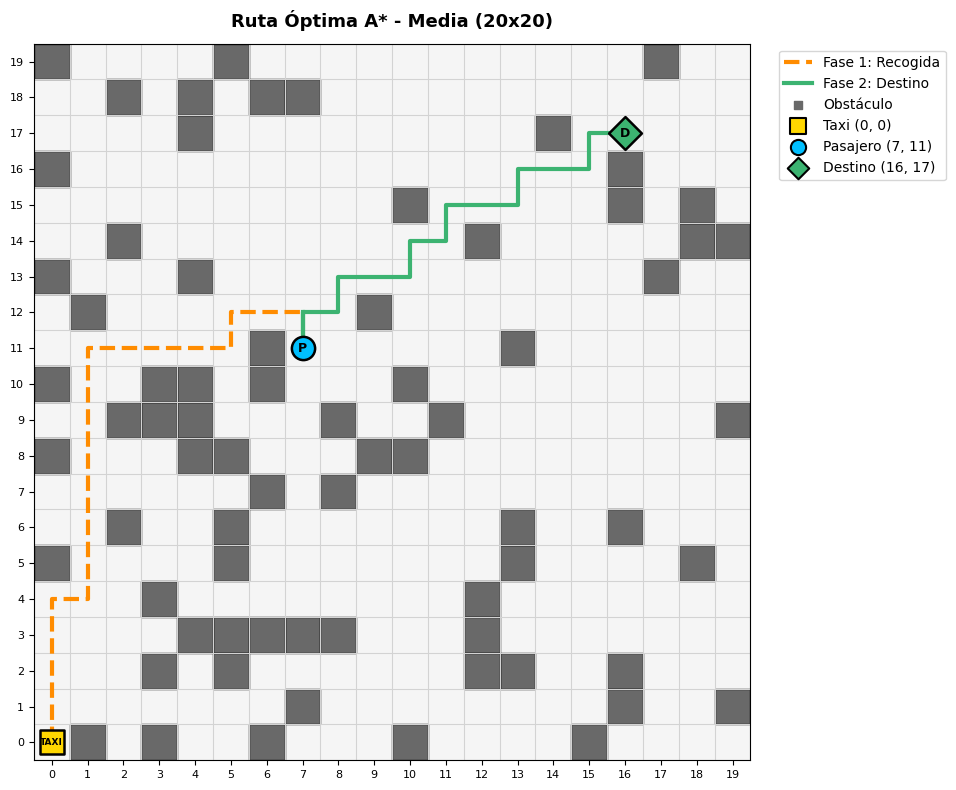

In [95]:
# Graficamos la ruta óptima encontrada por A* en este caso se usa la instancia media (20x20) [1]
instancia_seleccionada = instancias[1]
ciudad_seleccionada = instancia_seleccionada["ciudad"]
nodo_inicio = sp.node(instancia_seleccionada["inicio"])

busqueda_astar = sp.TreeSearch(
    nodo_inicio,
    ciudad_seleccionada.sucesor,
    ciudad_seleccionada.meta,
    strategy="a*",
    heuristic=ciudad_seleccionada.h_manhattan
)
solucion_astar = busqueda_astar.find()

dibujar_ciudad(
    ciudad_seleccionada,
    instancia_seleccionada["inicio"][0],
    ruta=solucion_astar.getPath(),
    titulo=f"Ruta Óptima A* - {instancia_seleccionada['nombre']}"
)


**Explicación de dominancia ($h_1$ domina a $h_2$):**
En una cuadrícula donde solo nos movemos en 4 direcciones, la distancia en línea recta (Euclidiana) siempre es menor o igual a doblar esquinas (Manhattan):
$$\sqrt{\Delta x^2 + \Delta y^2} \le |\Delta x| + |\Delta y| \implies h_{\text{euclidiana}}(n) \le h_{\text{manhattan}}(n)$$
Como la heurística Manhattan da valores más altos y más cercanos al costo real sin llegar a sobreestimarlo, **Manhattan domina a la Euclidiana**. En las pruebas prácticas, esto se comprueba porque A* con Manhattan explora menos de la mitad de nodos que la Euclidiana (199 vs 414 nodos en la instancia difícil) para encontrar la misma ruta óptima.


## 8. Conclusiones
* **Algoritmo ganador:** **A\* con Manhattan** fue por mucho la mejor estrategia. Siempre encuentra la ruta más corta (óptima) y explora muchísimos menos nodos que los demás métodos (solo 199 nodos en el mapa difícil, frente a 1,330 de BFS y 1,340 de Costo Uniforme).
* **Contraste entre lo estimado y lo medido:** En la Sección 4 estimamos que con detección de repetidos el espacio máximo era de $|S| \le 1,800$ estados. En la práctica real, BFS exploró **1,330 nodos** (muy cercano a la cota teórica al descontar el 22% de obstáculos), mientras que A* con Manhattan redujo drásticamente la búsqueda a solo **199 nodos**.
* **Comportamiento de DFS:** Aunque a veces encuentra una meta rápido, devuelve caminos muy malos y llenos de desvíos innecesarios (318 pasos en lugar de 52). No es adecuado para encontrar rutas cortas.
* **¿Qué haríamos diferente con más tiempo?**
  Podríamos agregar costos diferentes por calle para simular tráfico pesado o avenidas rápidas (haciendo que algunas calles cuesten más que otras usando `step_cost`), o ampliar el problema para que el taxi pueda atender múltiples solicitudes de pasajeros.


## 9. Referencias y Contribuciones
### Referencias
1. **Russell, S., & Norvig, P. (2021).** *Artificial Intelligence: A Modern Approach* (4ta ed.). Pearson.  
   *(Texto base del curso; modelado formal de espacios de estados, búsqueda no informada y búsqueda informada).*
2. **Hart, P. E., Nilsson, N. J., & Raphael, B. (1968).** *A Formal Basis for the Heuristic Determination of Minimum Cost Paths*. IEEE Transactions on Systems Science and Cybernetics, 4(2), 100–107.  
   *(Artículo seminal donde se propuso y demostró matemáticamente la optimalidad del algoritmo A* bajo heurísticas admisibles).*
3. **Dietterich, T. G. (2000).** *Hierarchical Reinforcement Learning with the MAXQ Value Function Decomposition*. Journal of Artificial Intelligence Research, 13, 227–303.  
   *(Artículo científico que formalizó el entorno del Taxi en una cuadrícula con fases secuenciales de recogida y entrega).*
4. **Pearl, J. (1984).** *Heuristics: Intelligent Search Strategies for Computer Problem Solving*. Addison-Wesley.  
   *(Referencia clásica sobre el análisis formal de dominancia de heurísticas y la técnica de relajación de restricciones).*
5. **Ortiz Béjar, J. (2024).** *Librería baile: Entornos y algoritmos para la enseñanza de Inteligencia Artificial*. Facultad de Ingeniería Eléctrica, UMSNH. Repositorio base: [https://github.com/kyriox/baile](https://github.com/kyriox/baile).

### Contribuciones individuales
* **Moisés Moreno Cortez:** Me encargué principalmente de la programación: implementé el código de `src/taxi.py` (la clase `CiudadTaxi`, las transiciones de movimiento, la condición de meta y el cálculo de las heurísticas), programé la visualización gráfica de la ciudad y configuré las celdas para ejecutar los algoritmos de búsqueda en el notebook.
* **César Ambris Salguero:** Me encargué del diseño experimental y el análisis: configuré las instancias de prueba (Fácil, Media y Difícil) con semillas fijas para que los resultados fueran reproducibles, realicé las pruebas de correctitud comparando A* contra BFS, y colaboré en el análisis de las tablas y redacción de conclusiones.
